In [1]:
CLASS_NAMES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Saving test1.jpeg to test1 (4).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


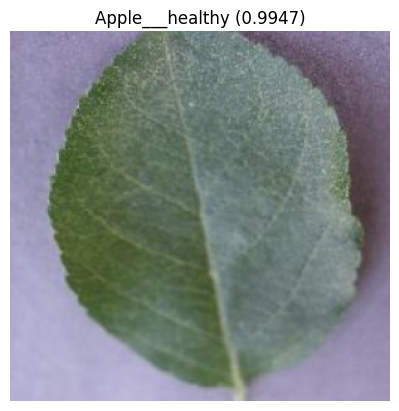

In [16]:
# =========================
# FULL INFERENCE CODE (UPLOAD + DISPLAY + TITLE = PREDICTION)
# =========================

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt


# ---- 2. Load model ----
model = tf.keras.models.load_model("/content/drive/MyDrive/plant_disease_model_final.keras")

IMG_SIZE = 224

# ---- 3. Preprocess ----
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# ---- 4. Predict ----
def predict_image(img_path):
    img = preprocess_image(img_path)
    preds = model.predict(img)

    idx = np.argmax(preds)
    confidence = np.max(preds)

    return CLASS_NAMES[idx], confidence

# ---- 5. Upload image ----
uploaded = files.upload()

# ---- 6. Get path ----
img_path = list(uploaded.keys())[0]

# ---- 7. Predict ----
pred_class, conf = predict_image(img_path)

# ---- 8. Display image with prediction as title ----
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{pred_class} ({conf:.4f})")
plt.axis('off')
plt.show()